This notebook loads and compares evaluation results across all models and languages. It reads the JSON result files saved by the individual evaluation pipelines and combines them into a single pandas dataframe for easy comparison. For each model and language combination, it extracts the mean and standard deviation of precision, recall, and NDCG at all k values. The resulting dataframe provides a unified overview of all experimental results, making it straightforward to compare model performance across languages and identify patterns. This notebook serves as the central place for result analysis and can be used to generate comparison tables for the thesis.

In [2]:
import json
import pandas as pd
import numpy as np
import os

def load_results(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

# Load all result files
files = {
    'E5 English': 'results_e5_small_english.json',
    'E5 French': 'results_e5_french_enlabels.json',
    'E5 French (native labels)': 'results_e5_french_nativelabels.json',
    'E5 Dutch': 'results_e5_dutch_enlabels.json',
    'E5 Dutch (native labels)': 'results_e5_dutch_nativelabels.json',
    'E5 German': 'results_e5_german_enlabels.json',
    'E5 German (native labels)': 'results_e5_german_nativelabels.json', 

    'E5 English (reranked)': 'results_e5_reranked_en_en_labels.json',
    'E5 French (reranked)': 'results_e5_reranked_fr_en_labels.json',
    'E5 French native (reranked)': 'results_e5_reranked_fr_native_labels.json',
    'E5 Dutch (reranked)': 'results_e5_reranked_nl_en_labels.json',
    'E5 Dutch native (reranked)': 'results_e5_reranked_nl_native_labels.json',
    'E5 German (reranked)': 'results_e5_reranked_de_en_labels.json',
    'E5 German native (reranked)': 'results_e5_reranked_de_native_labels.json',

    'LaBSE English': 'results_labse_english.json',
    'LaBSE French': 'results_labse_french_enlabels.json',
    'LaBSE French (native labels)': 'results_labse_french_nativelabels.json',
    'LaBSE Dutch': 'results_labse_dutch_enlabels.json',
    'LaBSE Dutch (native labels)': 'results_labse_dutch_nativelabels.json',
    'LaBSE German': 'results_labse_german_enlabels.json',
    'LaBSE German (native labels)': 'results_labse_german_nativelabels.json',

    'OpenAI English': 'results_openai_english.json',
    'OpenAI French': 'results_openai_french_enlabels.json',
    'OpenAI French (native labels)': 'results_openai_french_nativelabels.json',
    'OpenAI Dutch': 'results_openai_dutch_enlabels.json',
    'OpenAI Dutch (native labels)': 'results_openai_dutch_nativelabels.json',
    'OpenAI German': 'results_openai_german_enlabels.json',
    'OpenAI German (native labels)': 'results_openai_german_nativelabels.json'    
}

k_values = [5, 10, 20, 50, 100]

rows = []
for model_name, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"Missing: {filepath}")
        continue
    data = load_results(filepath)
    for k in k_values:
        rows.append({
            'Model': model_name,
            'k': k,
            'Precision': data['metrics']['precision'][str(k)]['mean'],
            'Recall': data['metrics']['recall'][str(k)]['mean'],
            'NDCG': data['metrics']['ndcg'][str(k)]['mean'],
            'Precision_std': data['metrics']['precision'][str(k)]['std'],
            'Recall_std': data['metrics']['recall'][str(k)]['std'],
            'NDCG_std': data['metrics']['ndcg'][str(k)]['std'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                        Model   k  Precision   Recall     NDCG  Precision_std  Recall_std  NDCG_std
                   E5 English   5   0.085800 0.073409 0.095819       0.126263    0.120769  0.153945
                   E5 English  10   0.068720 0.120321 0.108793       0.077882    0.151027  0.145383
                   E5 English  20   0.053710 0.185980 0.137492       0.047421    0.178351  0.148413
                   E5 English  50   0.035244 0.300248 0.178165       0.023066    0.208393  0.148692
                   E5 English 100   0.024260 0.408209 0.209835       0.013020    0.217514  0.144981
                    E5 French   5   0.049560 0.045032 0.057713       0.097241    0.094573  0.120798
                    E5 French  10   0.046040 0.080313 0.070990       0.063658    0.117634  0.113446
                    E5 French  20   0.037060 0.123831 0.090979       0.040553    0.141754  0.117930
                    E5 French  50   0.024996 0.204539 0.119942       0.020982    0.173996  0.120891


                        Model   k  Precision   Recall     NDCG  Precision_std  Recall_std  NDCG_std
                   E5 English   5   0.085800 0.073409 0.095819       0.126263    0.120769  0.153945
                   E5 English  10   0.068720 0.120321 0.108793       0.077882    0.151027  0.145383
                   E5 English  20   0.053710 0.185980 0.137492       0.047421    0.178351  0.148413
                   E5 English  50   0.035244 0.300248 0.178165       0.023066    0.208393  0.148692
                   E5 English 100   0.024260 0.408209 0.209835       0.013020    0.217514  0.144981
                    E5 French   5   0.049560 0.045032 0.057713       0.097241    0.094573  0.120798
                    E5 French  10   0.046040 0.080313 0.070990       0.063658    0.117634  0.113446
                    E5 French  20   0.037060 0.123831 0.090979       0.040553    0.141754  0.117930
                    E5 French  50   0.024996 0.204539 0.119942       0.020982    0.173996  0.120891


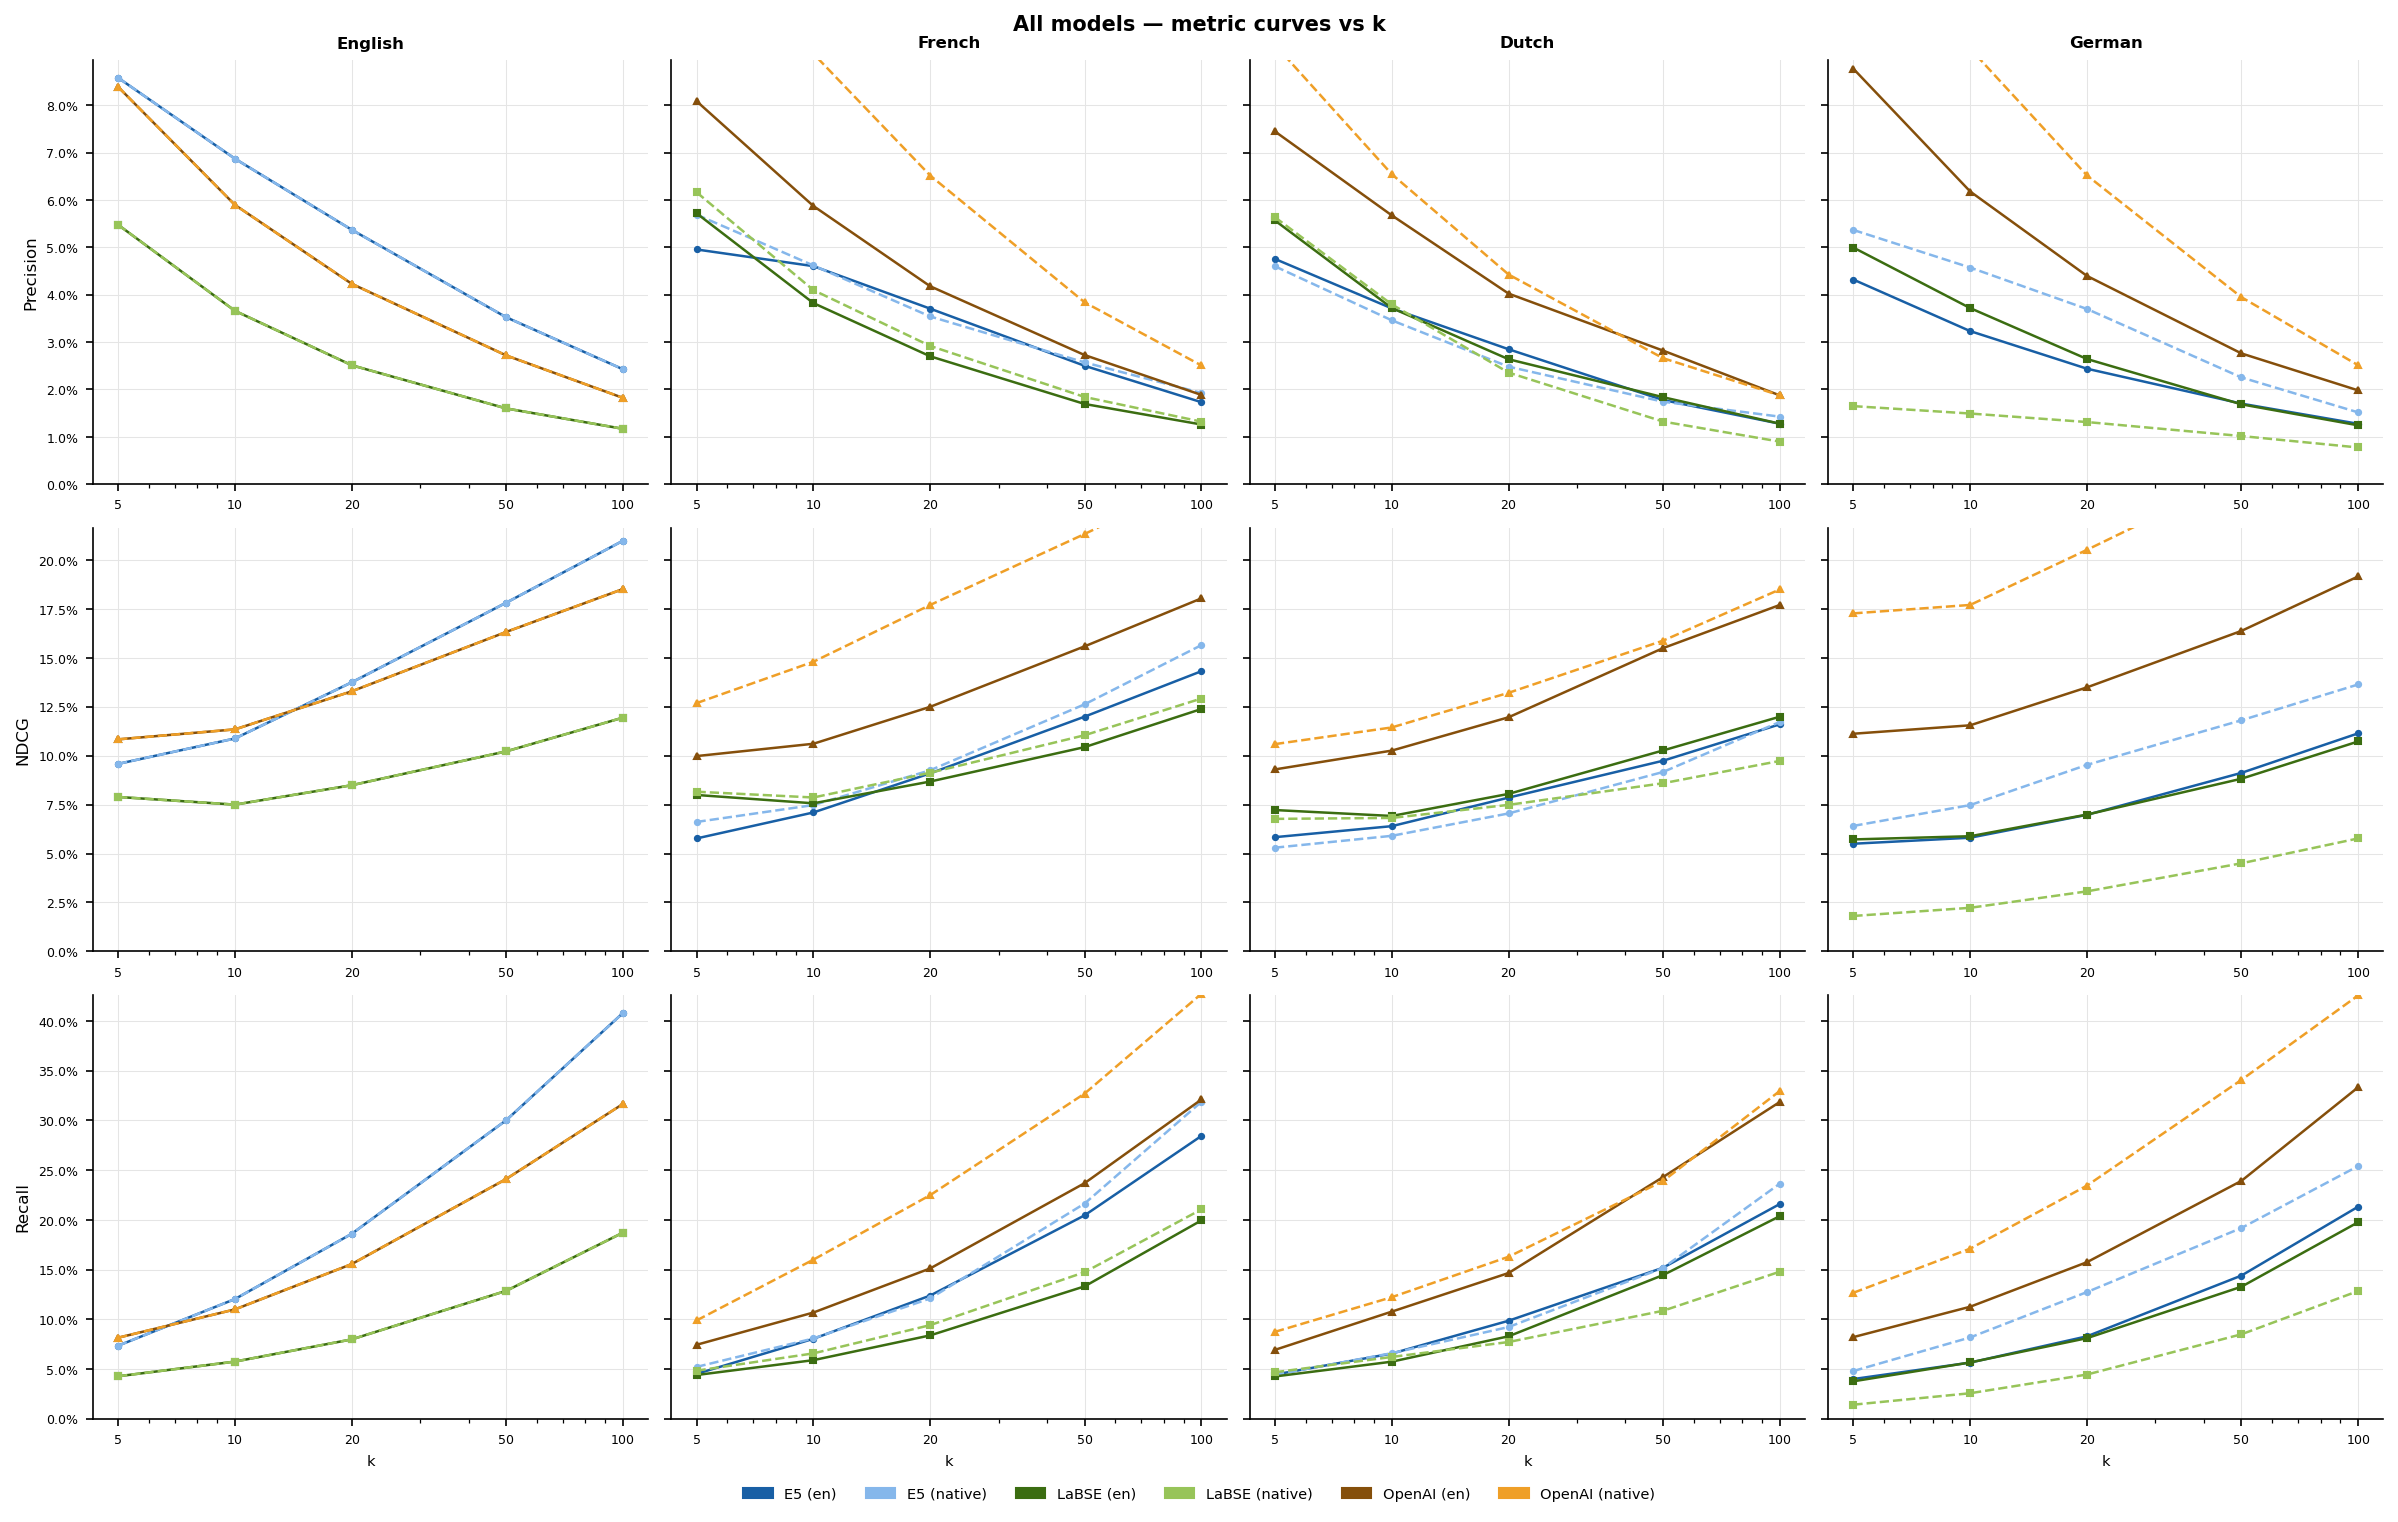

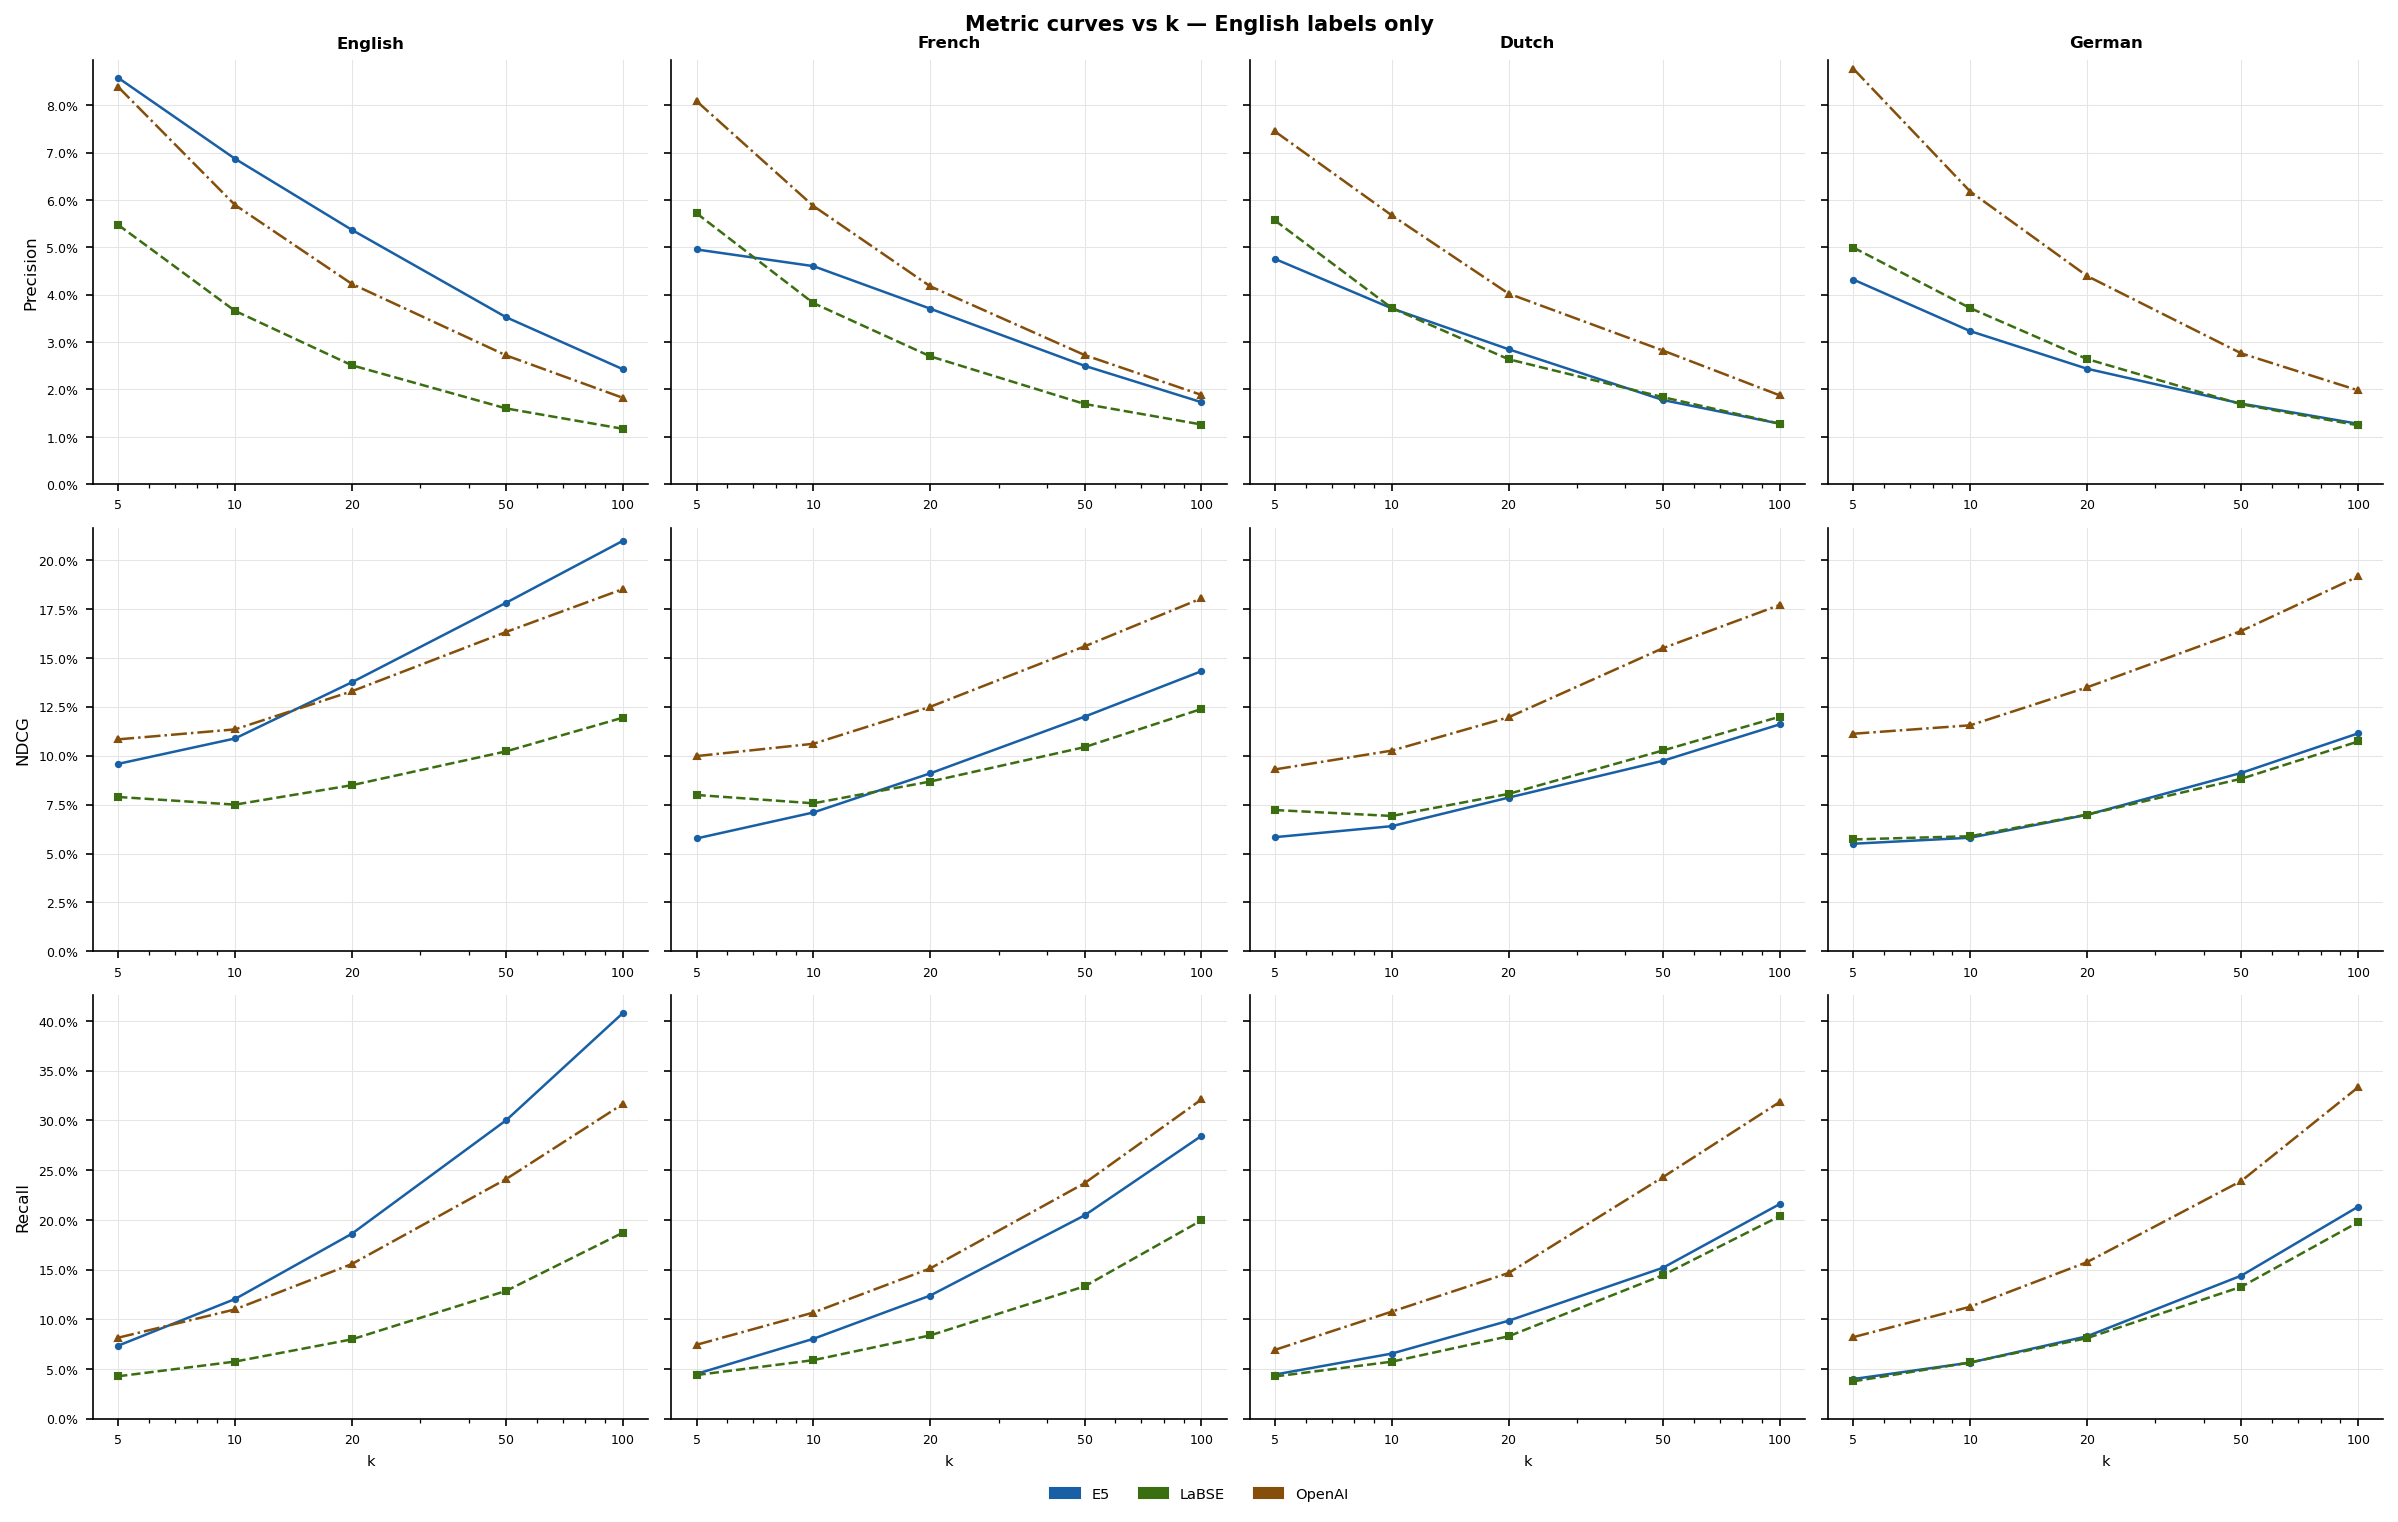

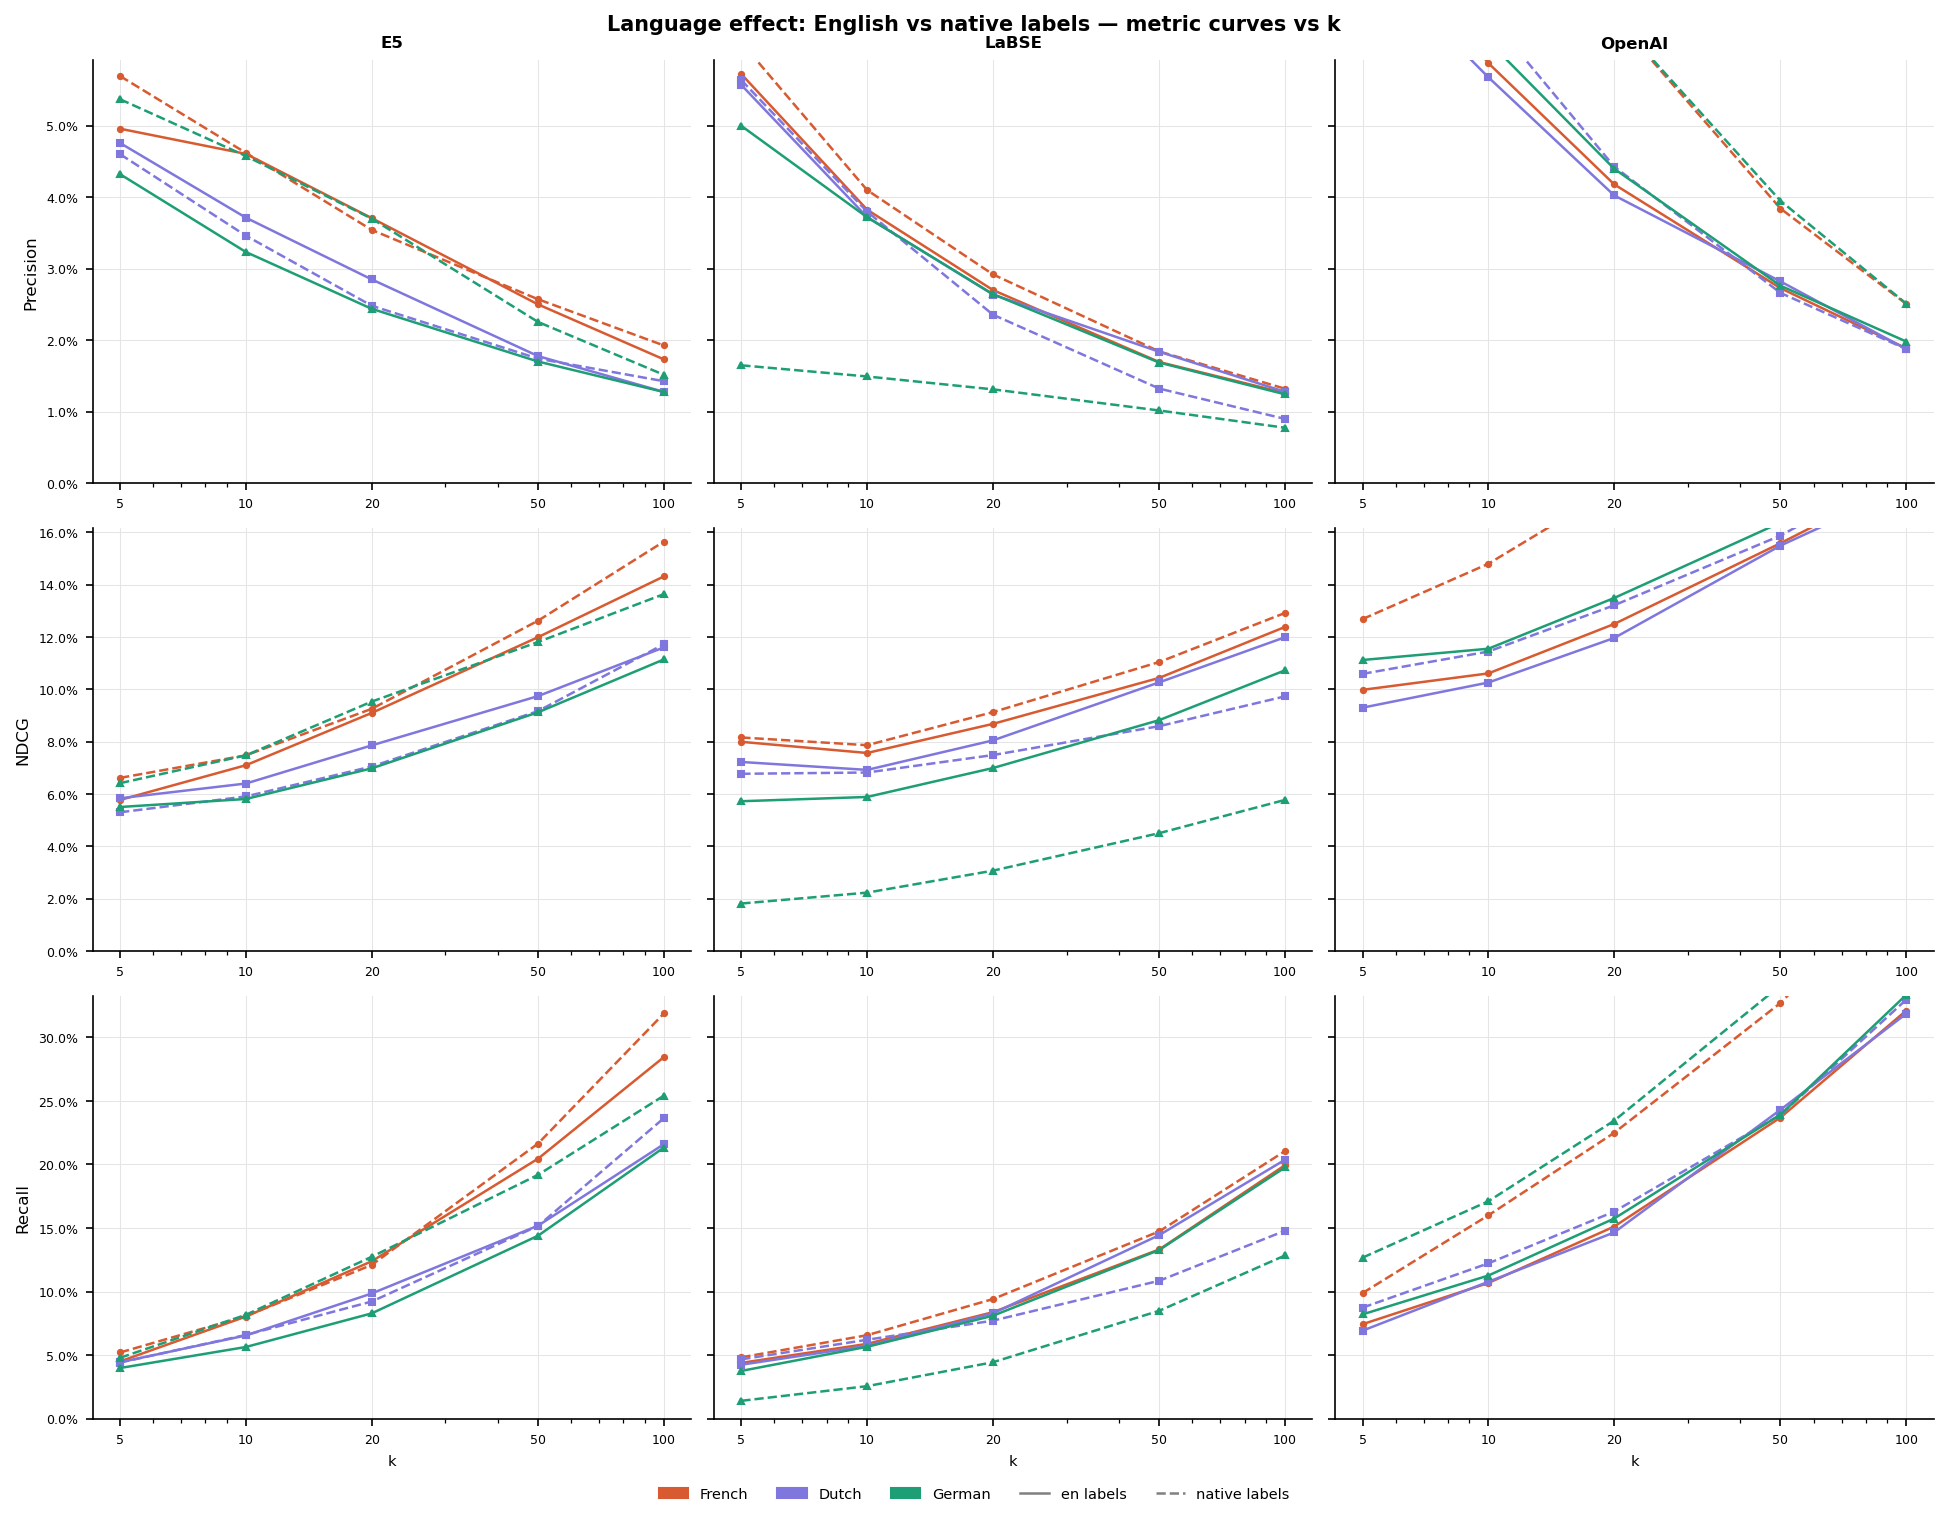

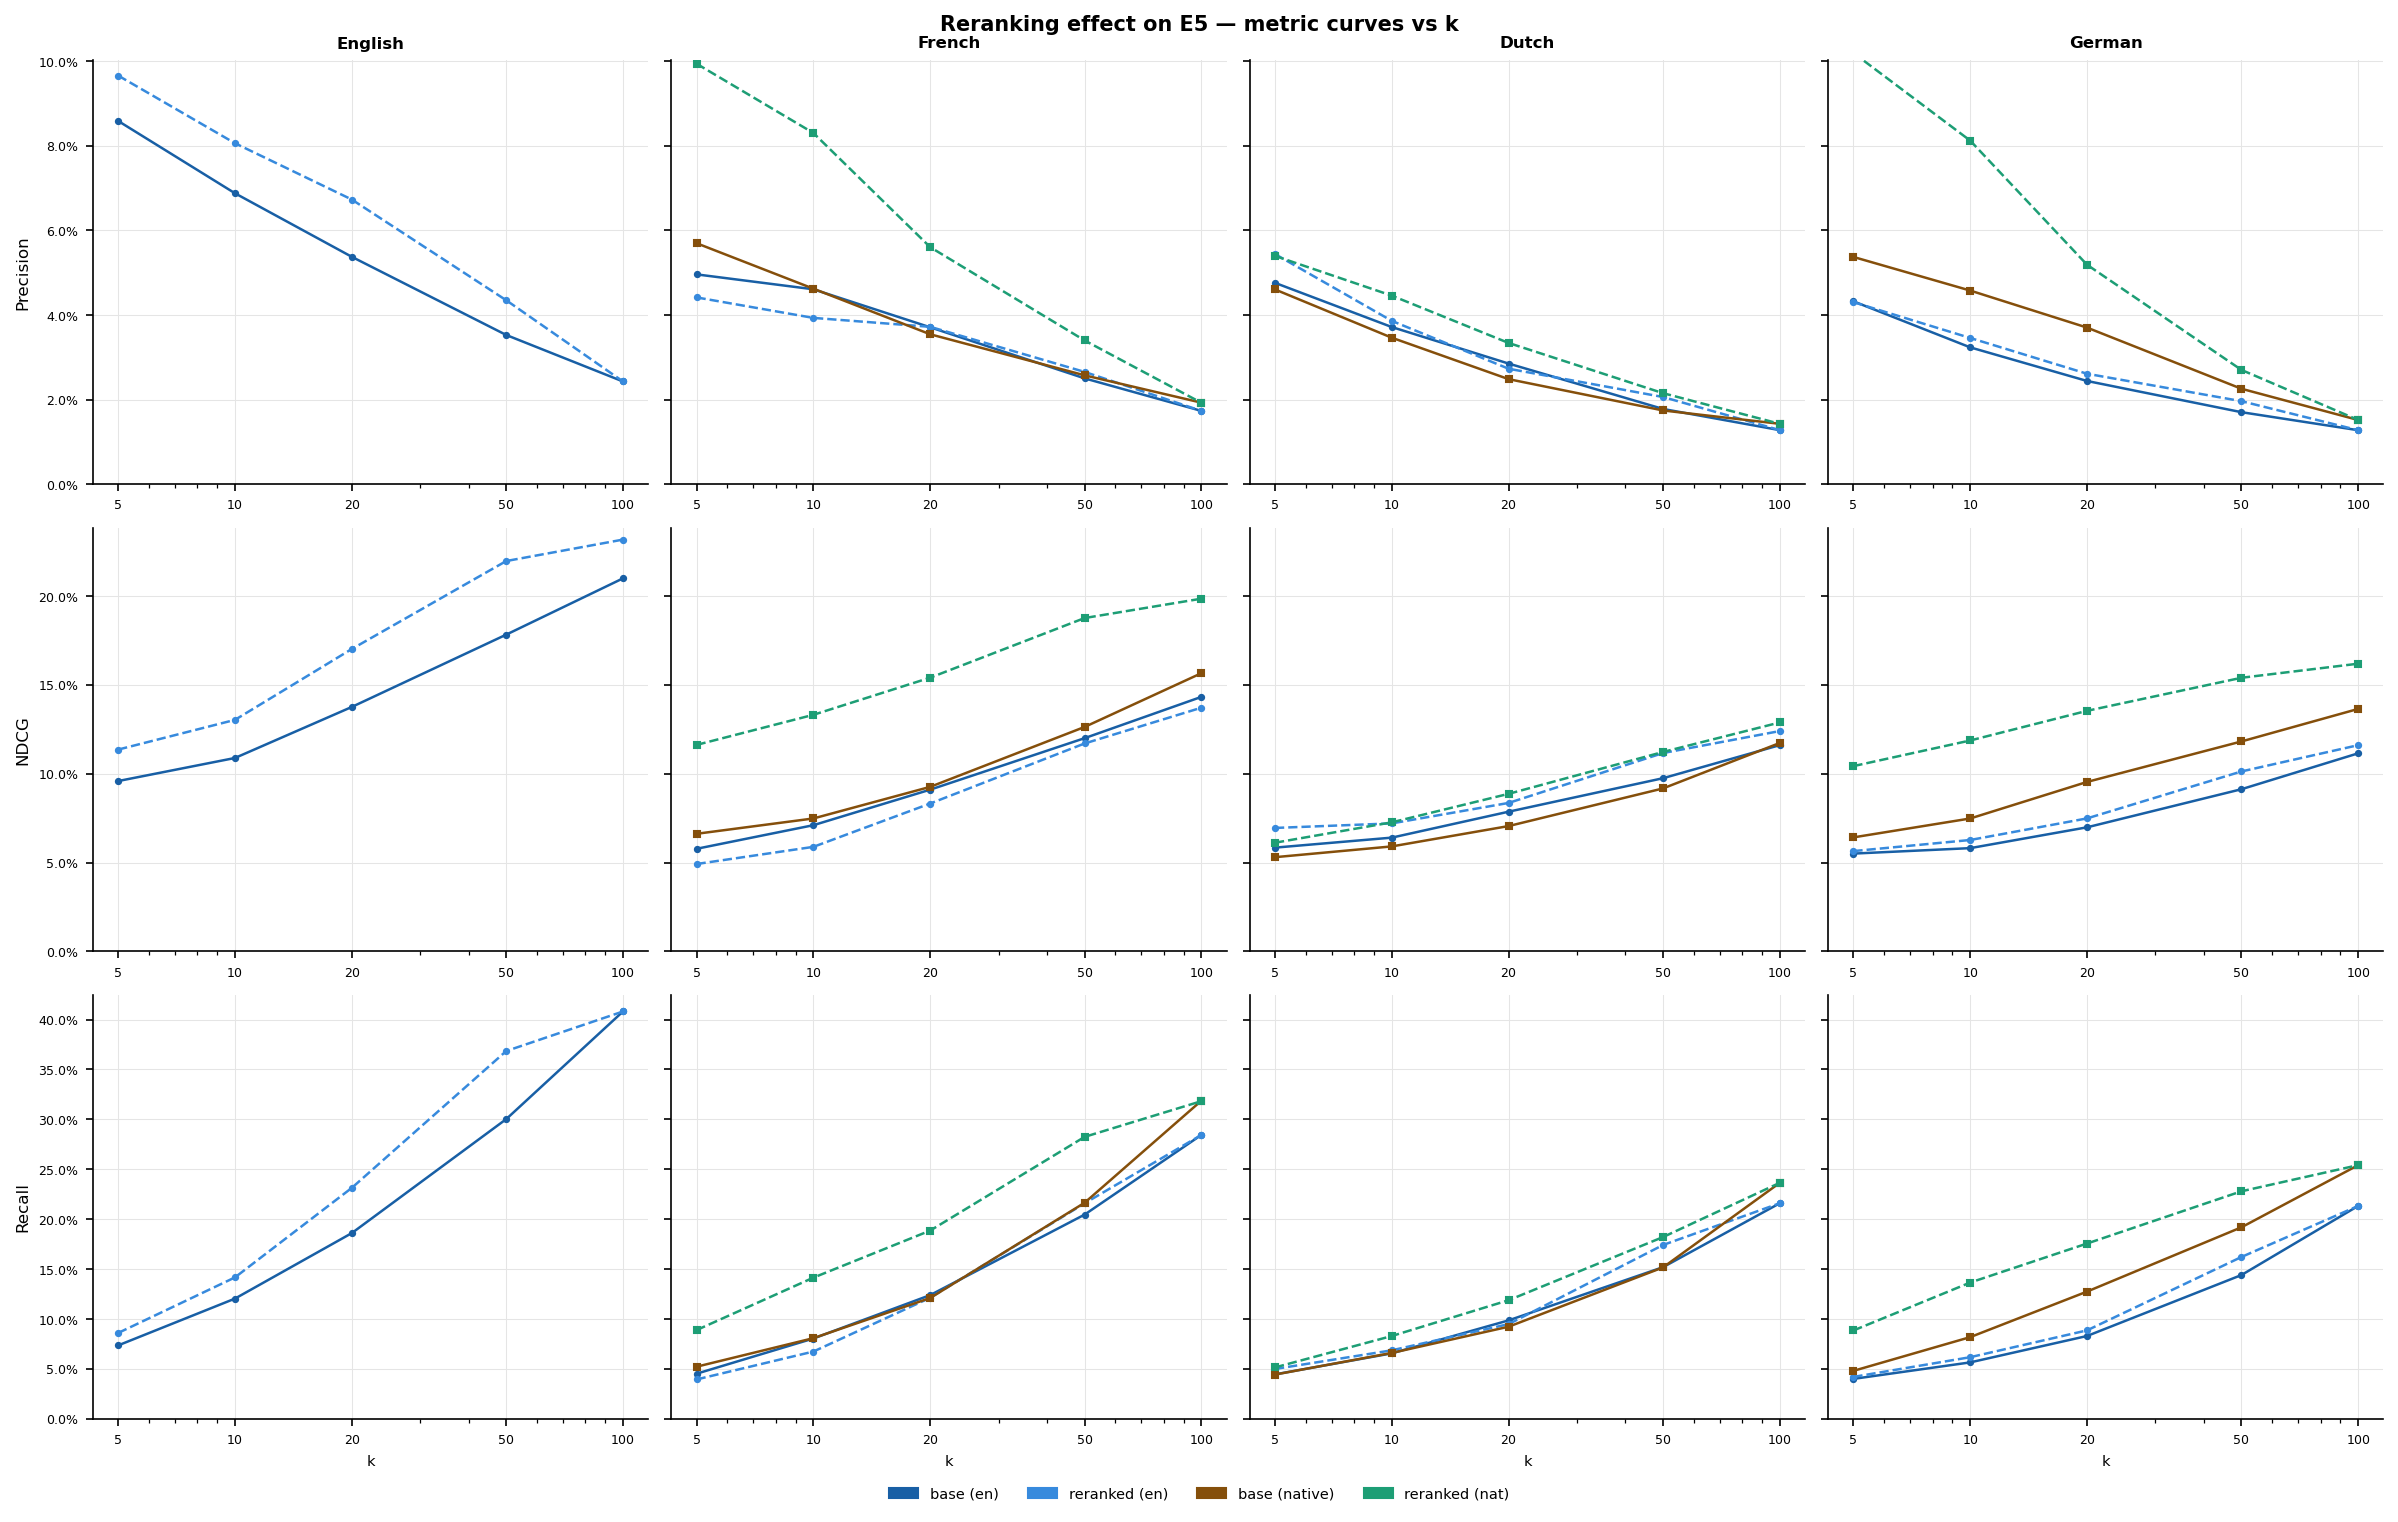

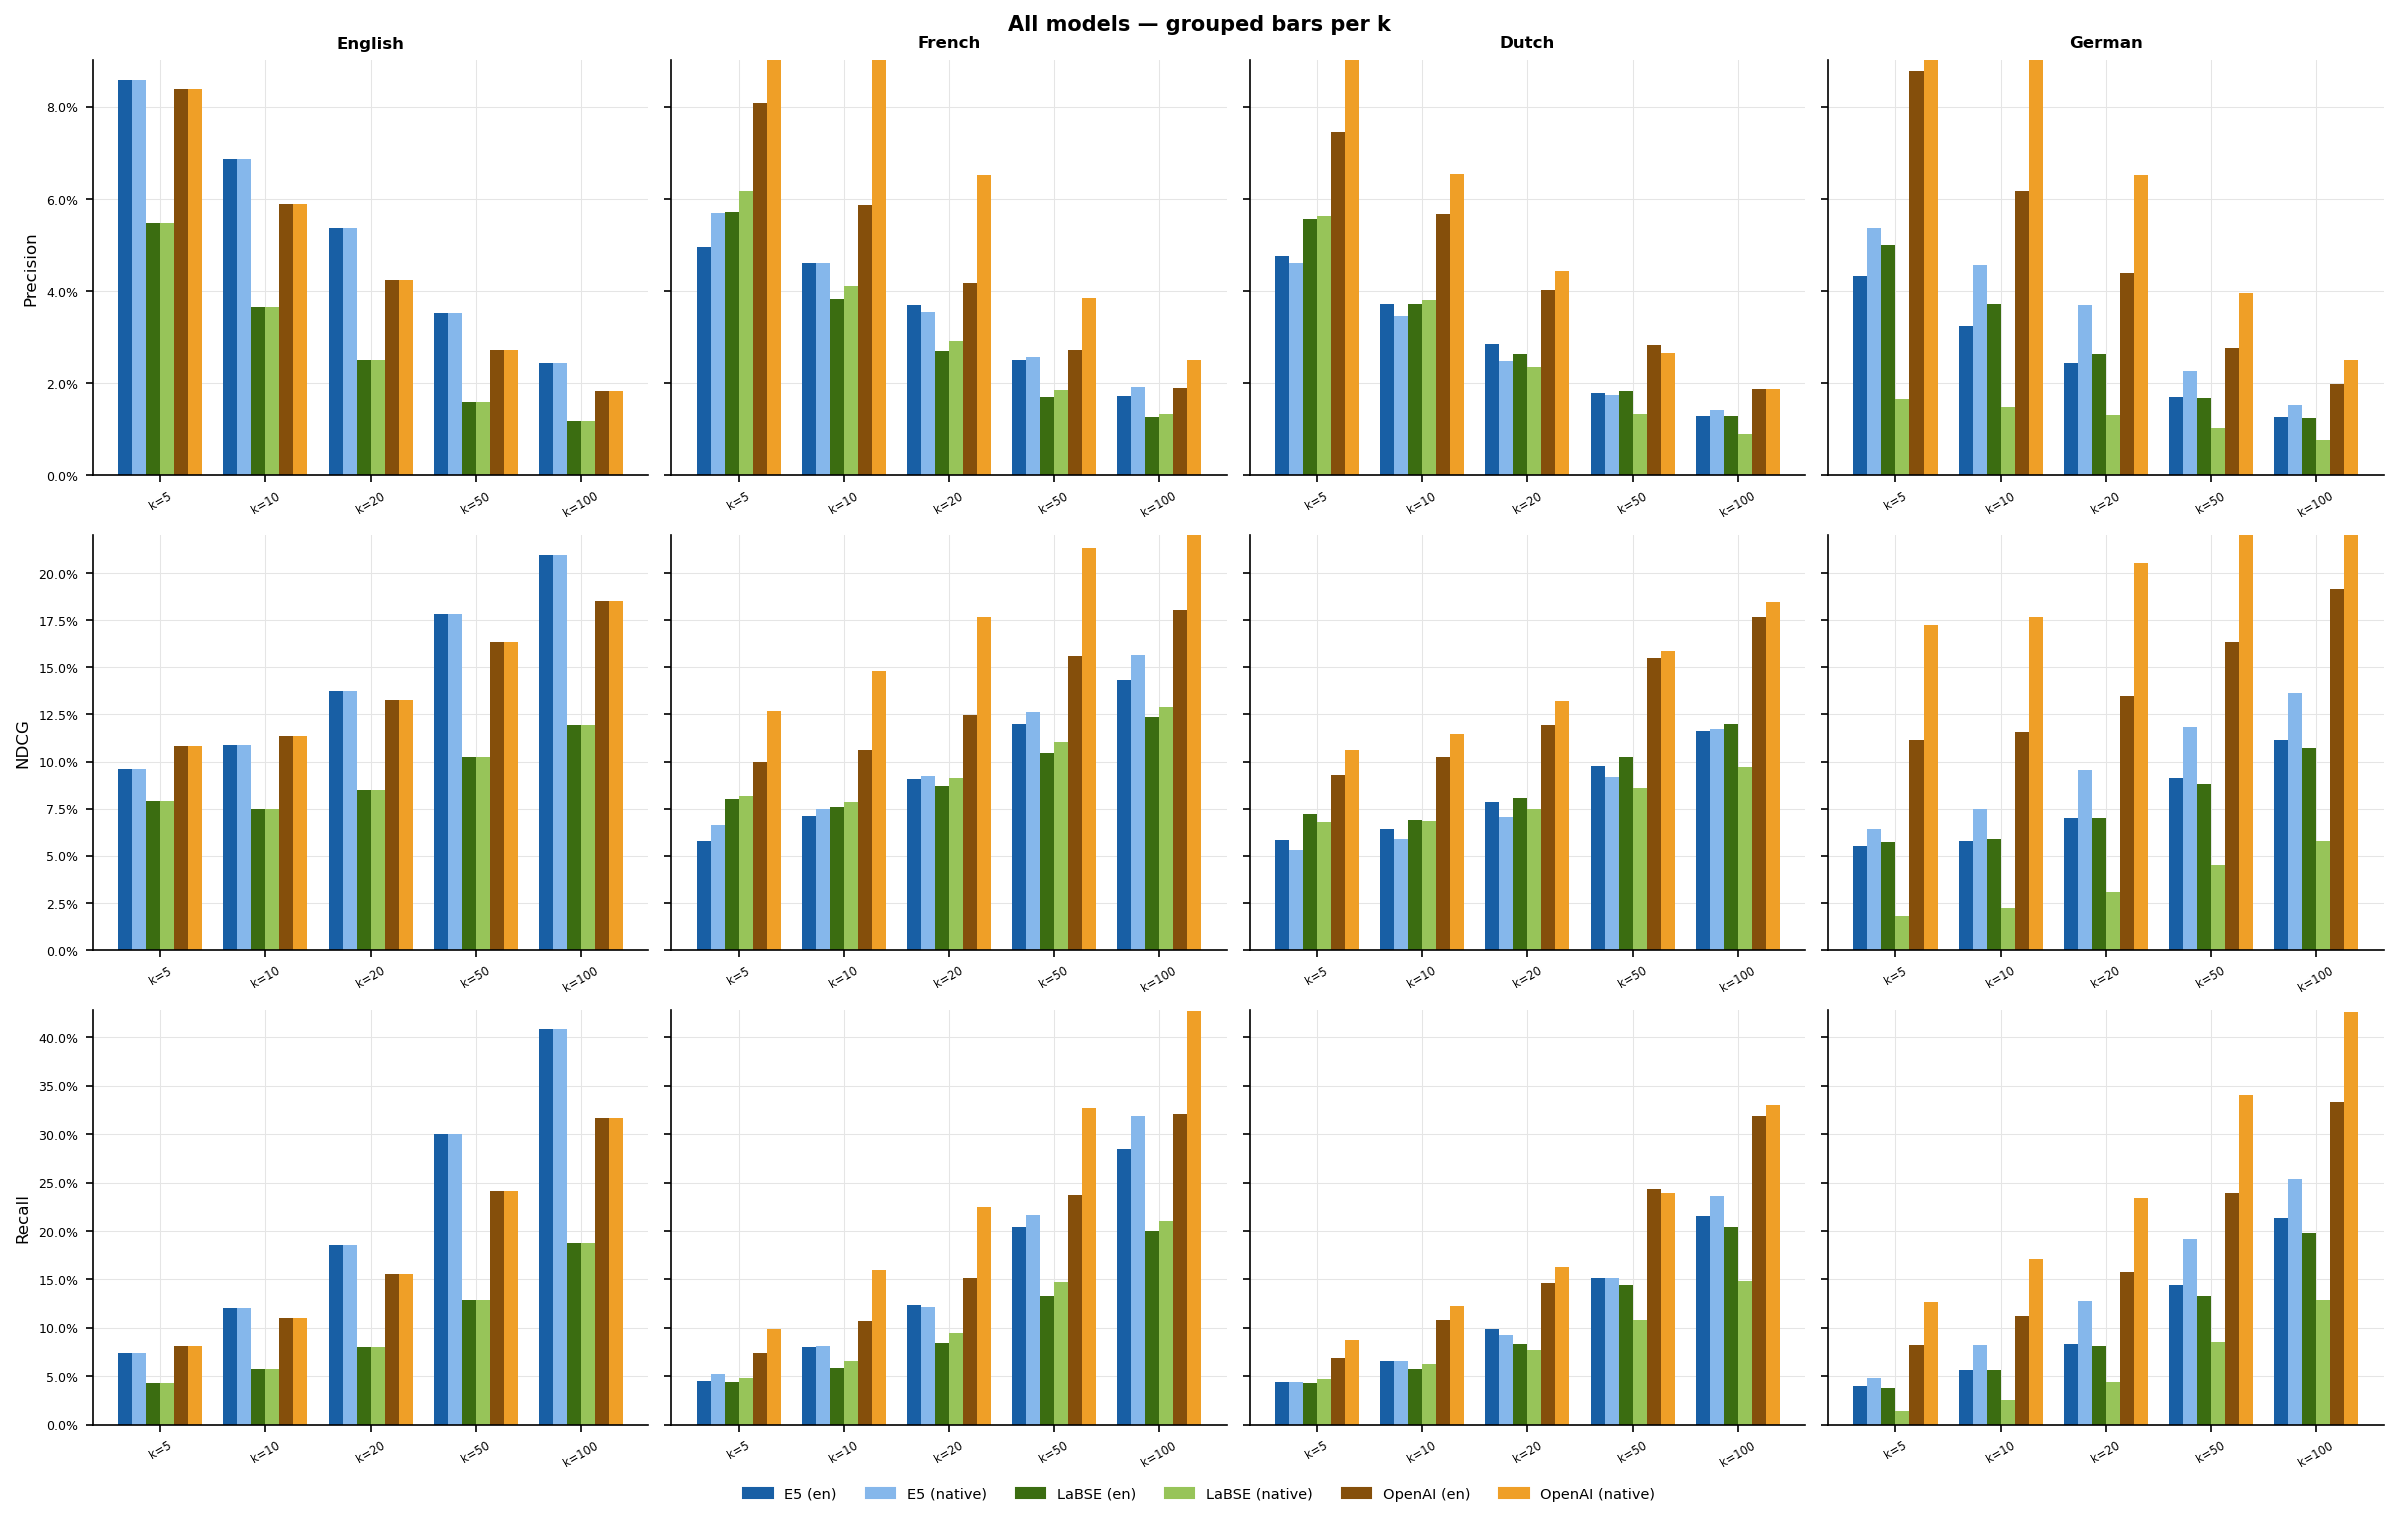

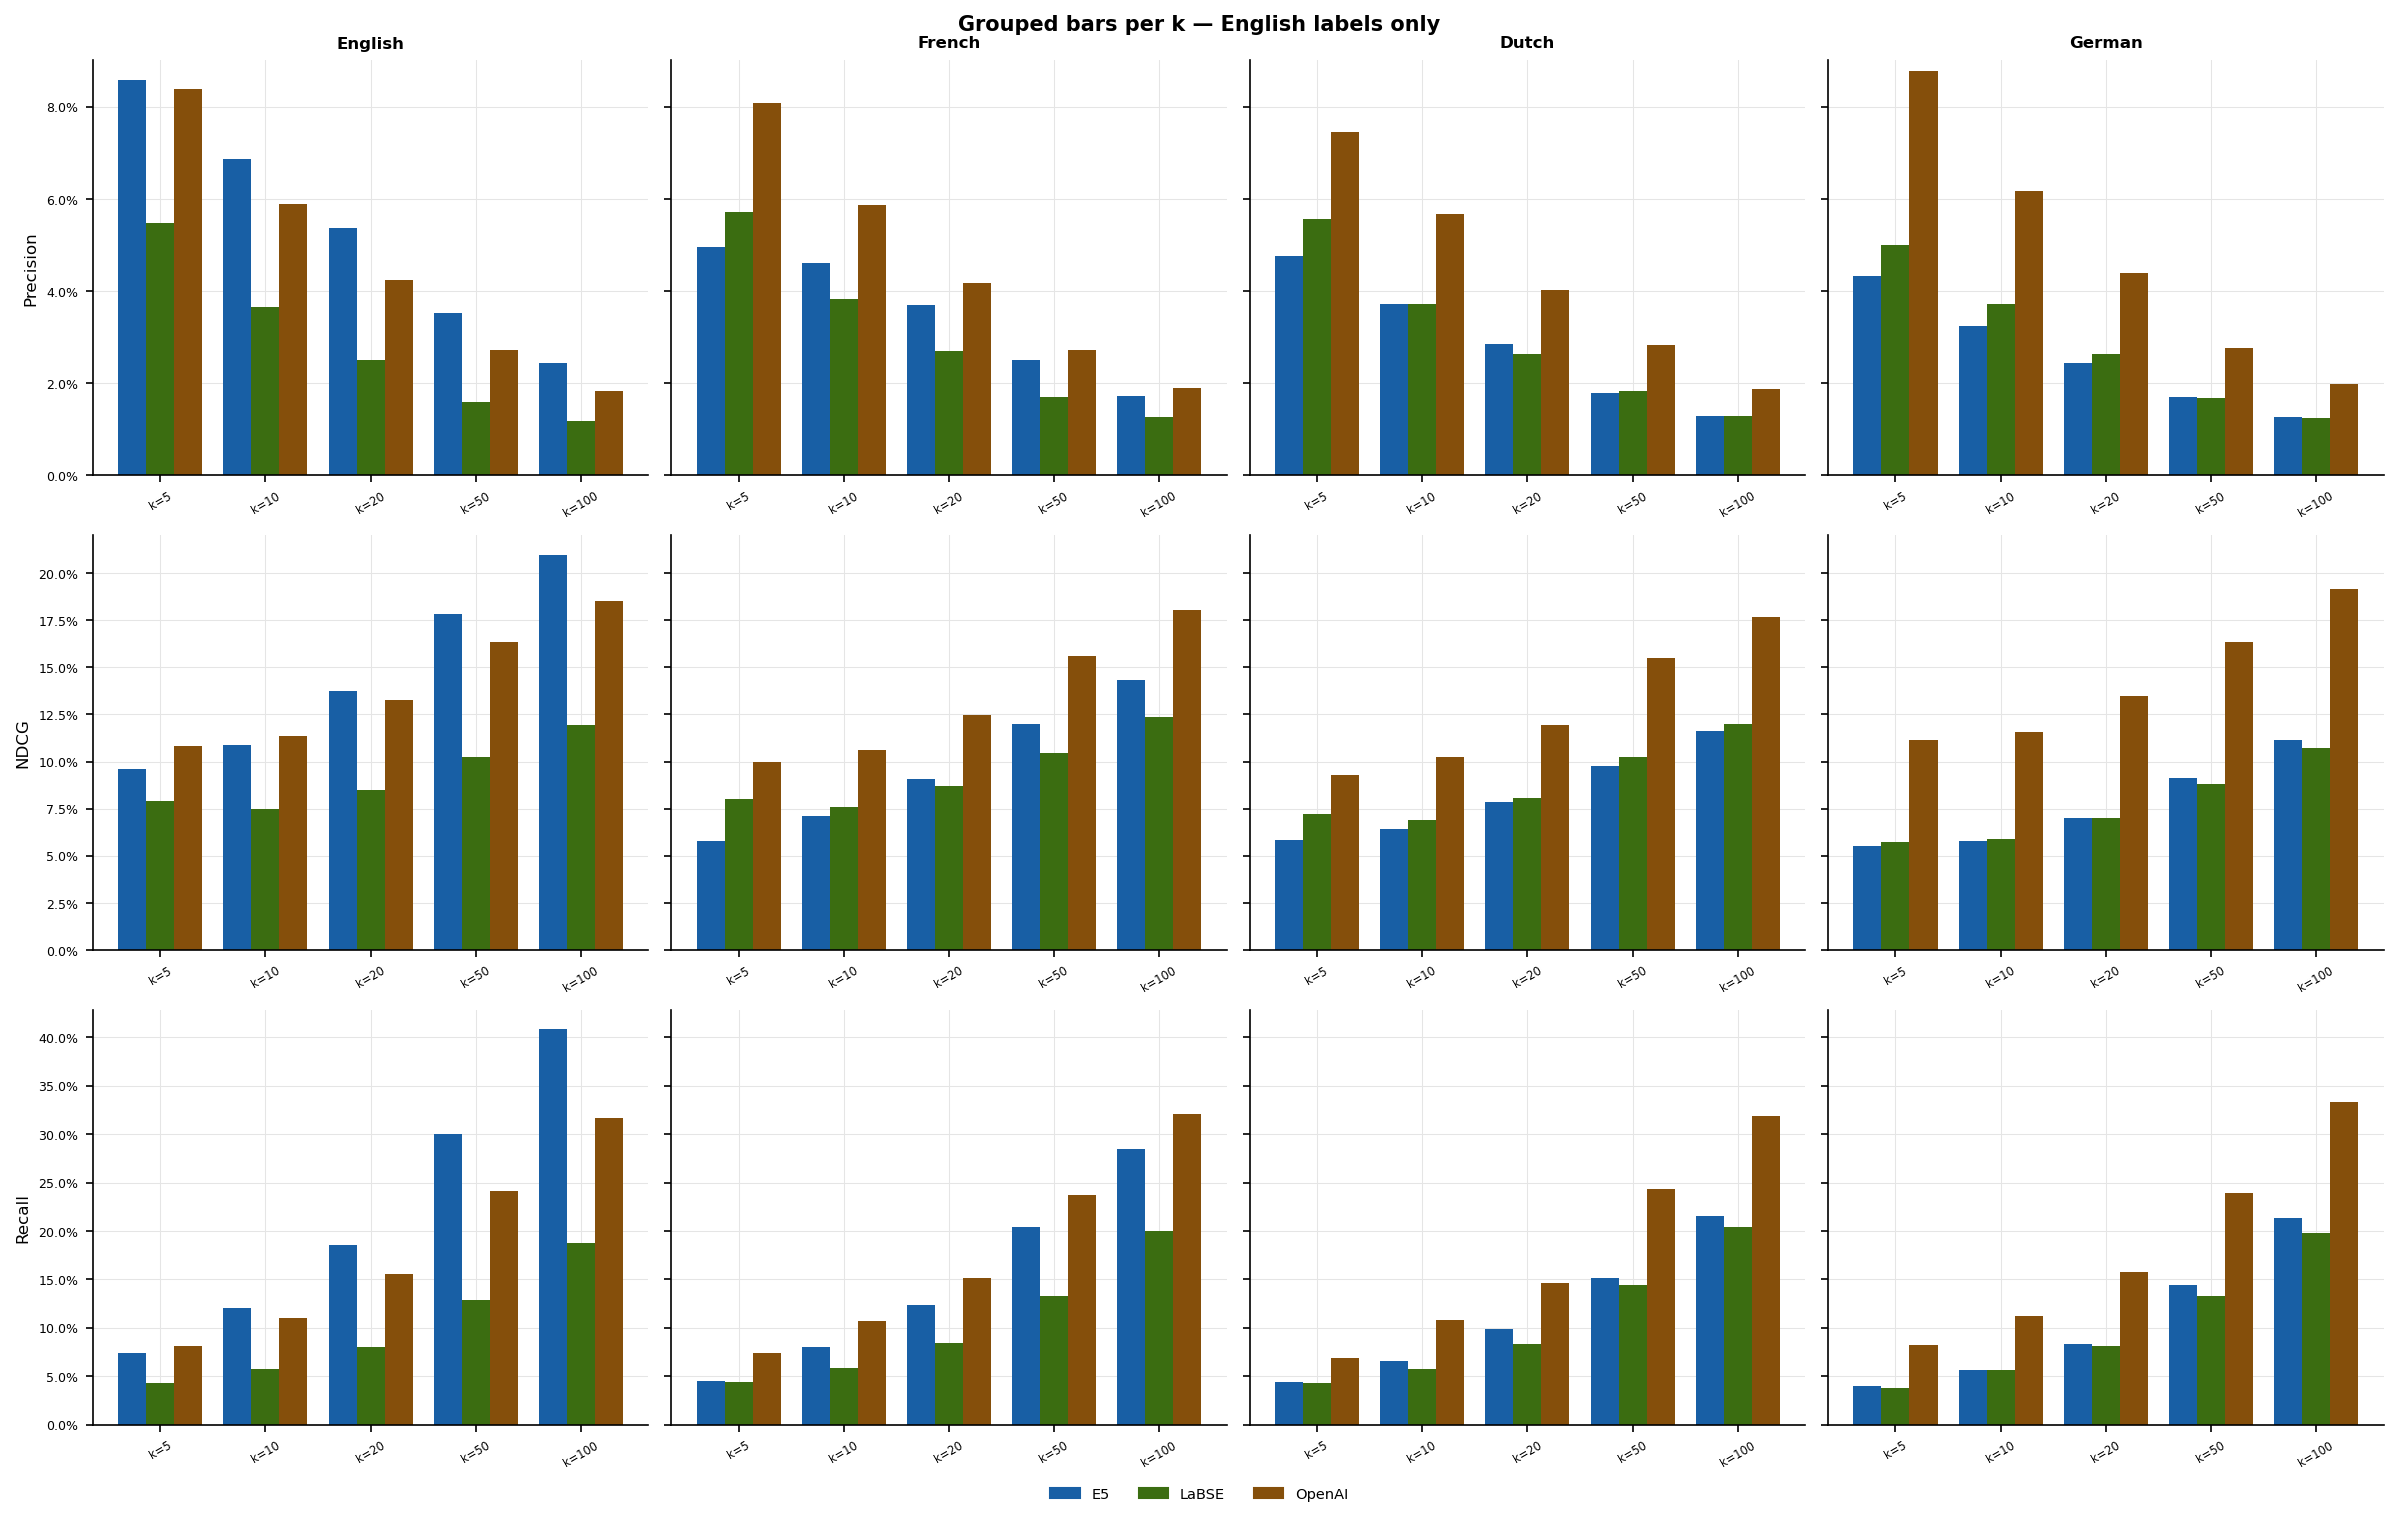

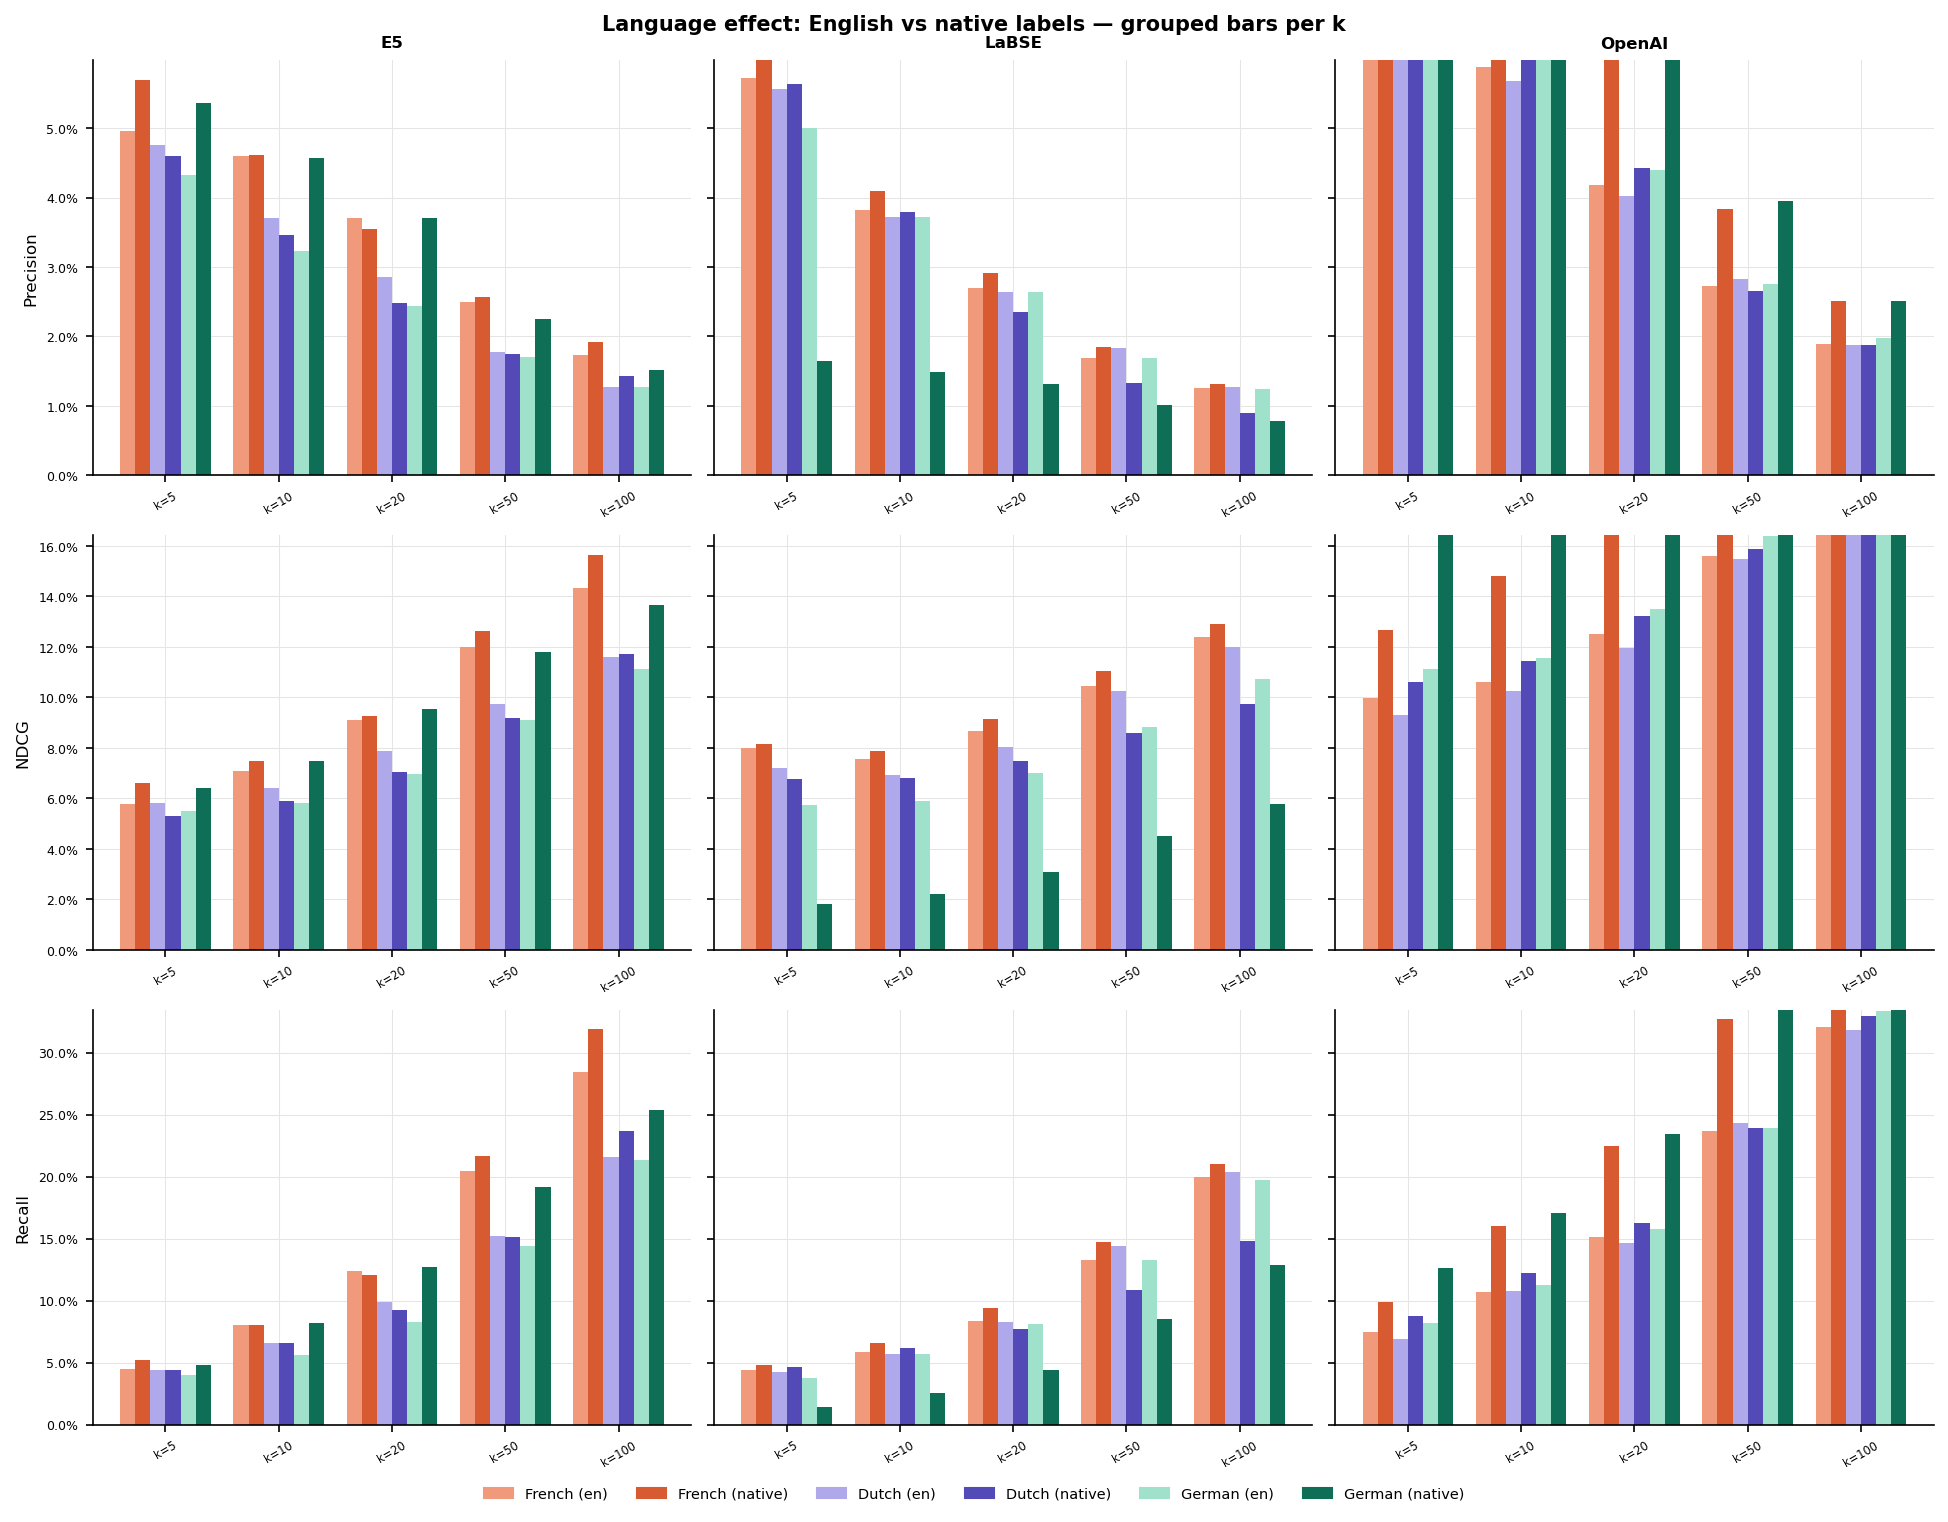

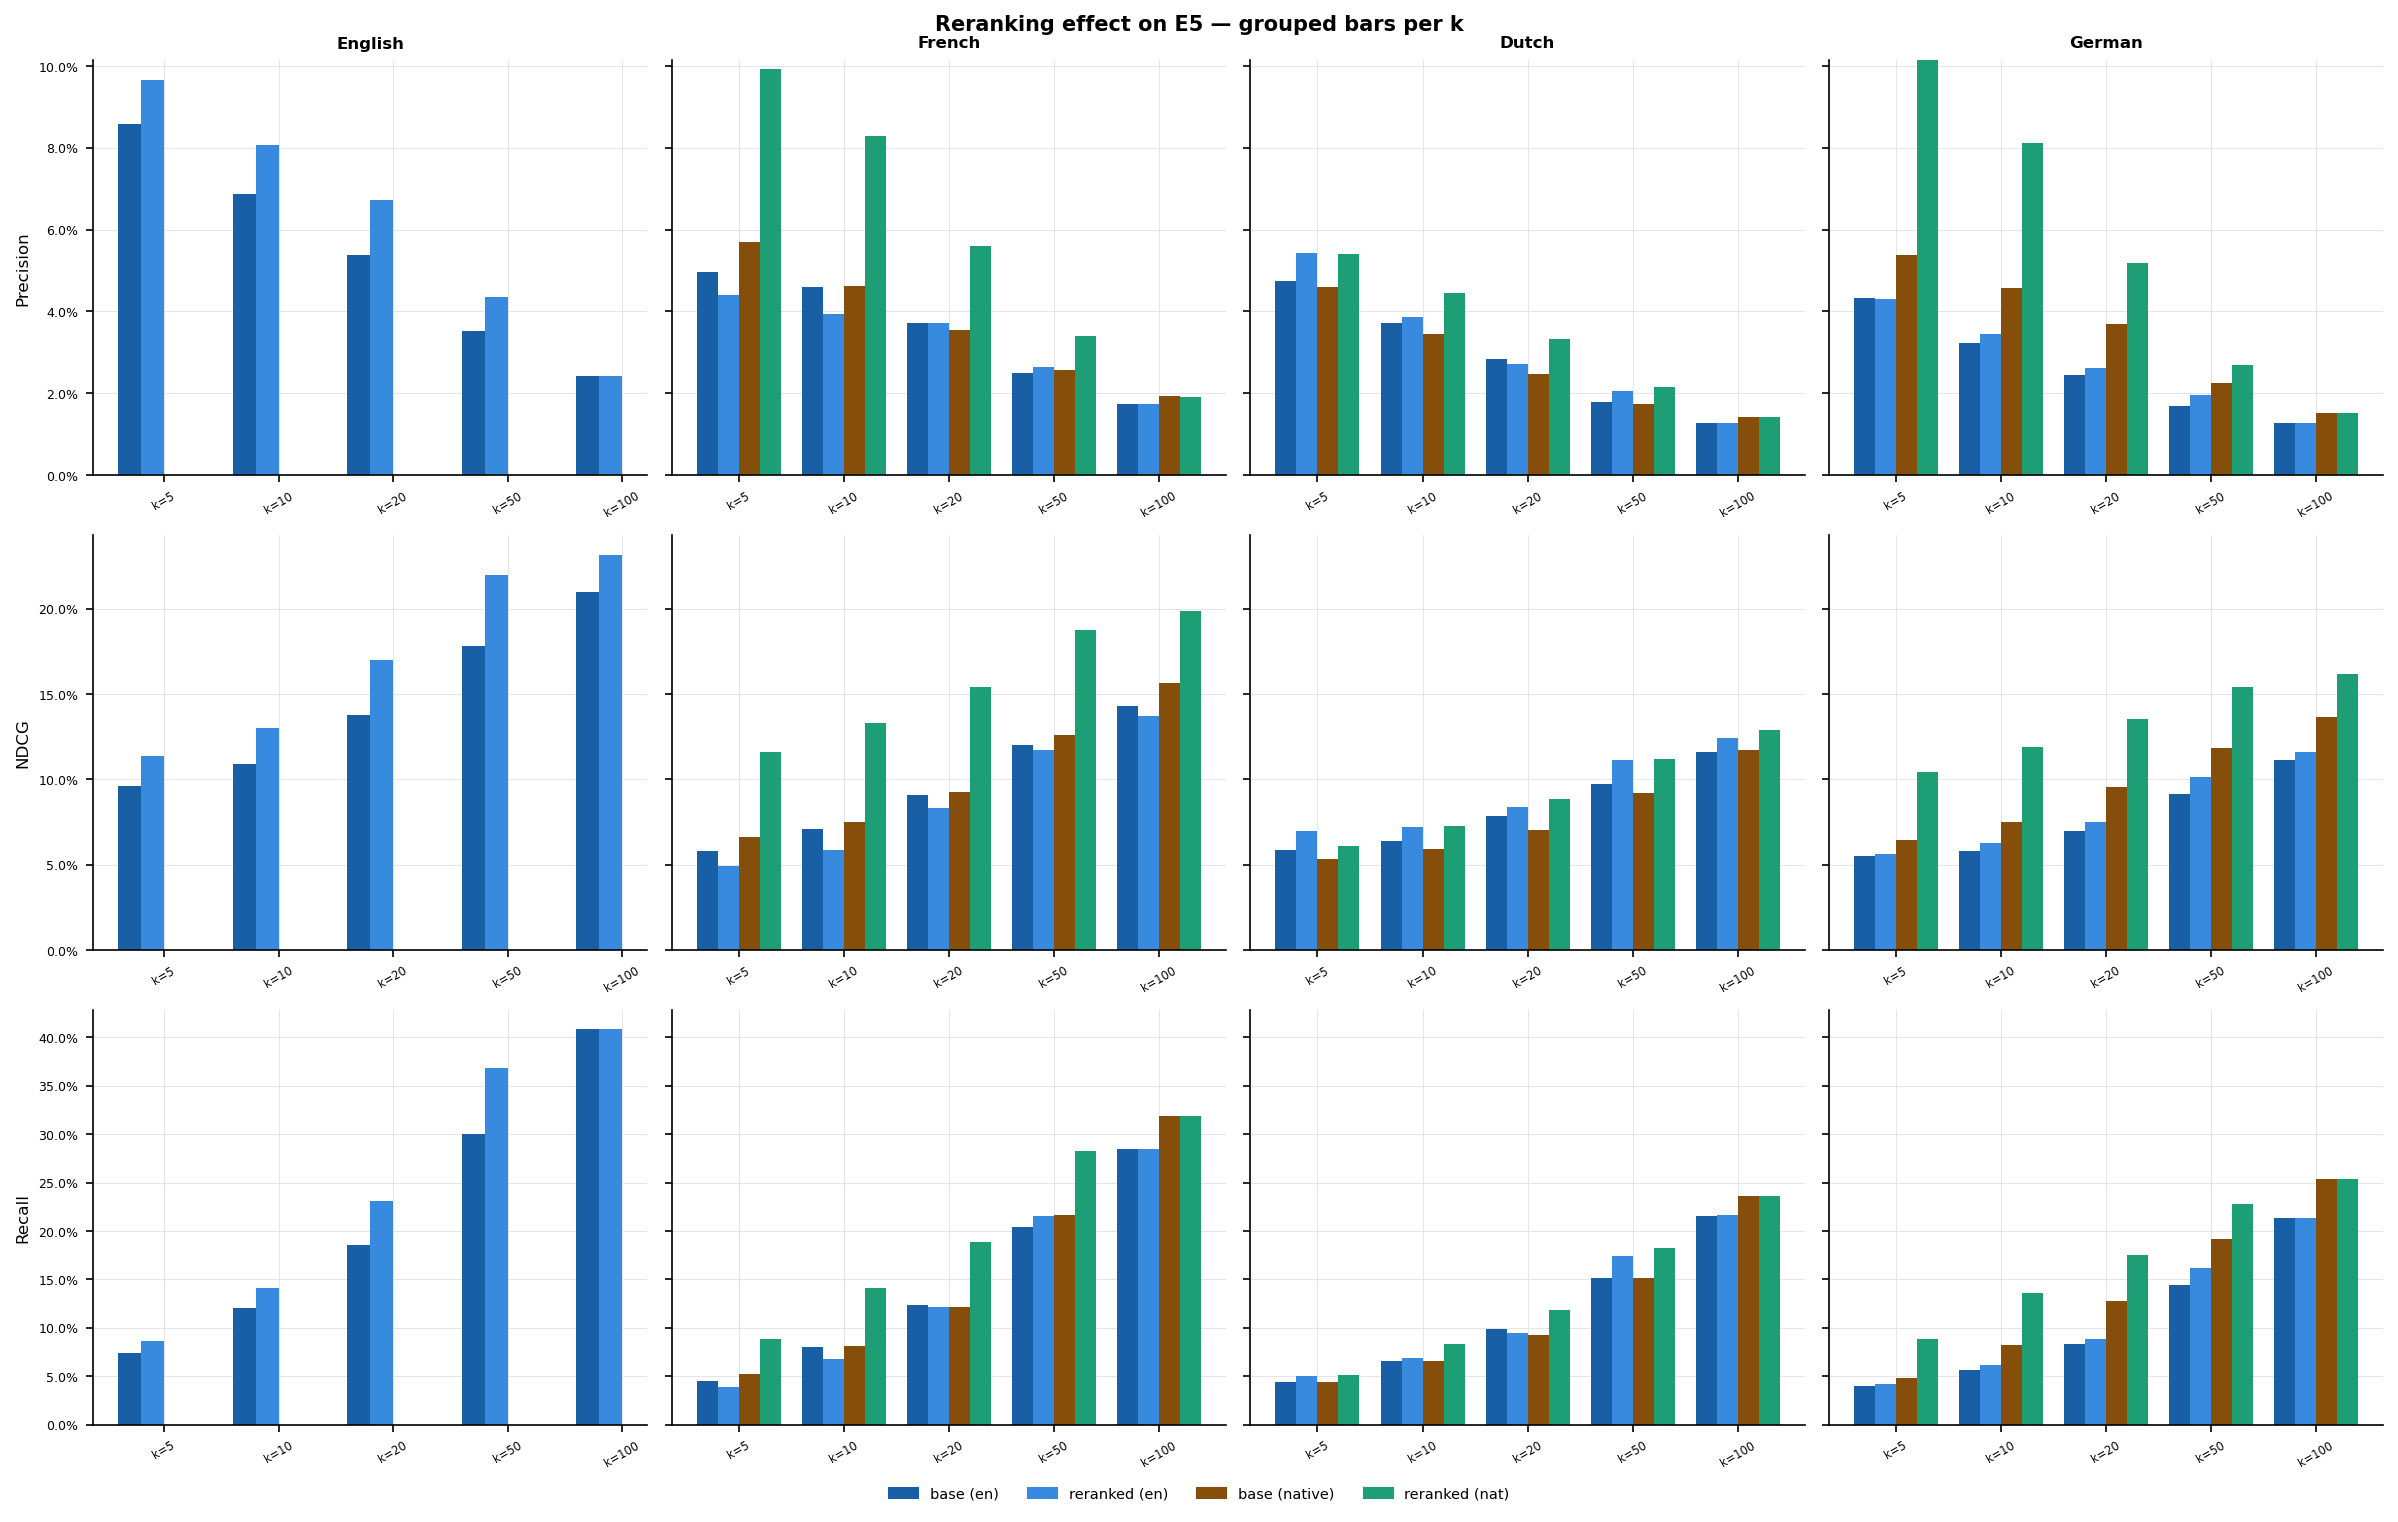

In [4]:
# ── CELL 1: load data, print table, and generate figures ─────────────────────

import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_results(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

files = {
    'E5 English':                   'results_e5_small_english.json',
    'E5 French':                    'results_e5_french_enlabels.json',
    'E5 French (native labels)':    'results_e5_french_nativelabels.json',
    'E5 Dutch':                     'results_e5_dutch_enlabels.json',
    'E5 Dutch (native labels)':     'results_e5_dutch_nativelabels.json',
    'E5 German':                    'results_e5_german_enlabels.json',
    'E5 German (native labels)':    'results_e5_german_nativelabels.json',
    'E5 English (reranked)':        'results_e5_reranked_en_en_labels.json',
    'E5 French (reranked)':         'results_e5_reranked_fr_en_labels.json',
    'E5 French native (reranked)':  'results_e5_reranked_fr_native_labels.json',
    'E5 Dutch (reranked)':          'results_e5_reranked_nl_en_labels.json',
    'E5 Dutch native (reranked)':   'results_e5_reranked_nl_native_labels.json',
    'E5 German (reranked)':         'results_e5_reranked_de_en_labels.json',
    'E5 German native (reranked)':  'results_e5_reranked_de_native_labels.json',
    'LaBSE English':                'results_labse_english.json',
    'LaBSE French':                 'results_labse_french_enlabels.json',
    'LaBSE French (native labels)': 'results_labse_french_nativelabels.json',
    'LaBSE Dutch':                  'results_labse_dutch_enlabels.json',
    'LaBSE Dutch (native labels)':  'results_labse_dutch_nativelabels.json',
    'LaBSE German':                 'results_labse_german_enlabels.json',
    'LaBSE German (native labels)': 'results_labse_german_nativelabels.json',
    'OpenAI English':               'results_openai_english.json',
    'OpenAI French':                'results_openai_french_enlabels.json',
    'OpenAI French (native labels)':'results_openai_french_nativelabels.json',
    'OpenAI Dutch':                 'results_openai_dutch_enlabels.json',
    'OpenAI Dutch (native labels)': 'results_openai_dutch_nativelabels.json',
    'OpenAI German':                'results_openai_german_enlabels.json',
    'OpenAI German (native labels)':'results_openai_german_nativelabels.json',
}

k_values = [5, 10, 20, 50, 100]
rows = []

for model_name, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"Missing: {filepath}")
        continue
    data = load_results(filepath)
    for k in k_values:
        rows.append({
            'Model':         model_name,
            'k':             k,
            'Precision':     data['metrics']['precision'][str(k)]['mean'],
            'Recall':        data['metrics']['recall'][str(k)]['mean'],
            'NDCG':          data['metrics']['ndcg'][str(k)]['mean'],
            'Precision_std': data['metrics']['precision'][str(k)]['std'],
            'Recall_std':    data['metrics']['recall'][str(k)]['std'],
            'NDCG_std':      data['metrics']['ndcg'][str(k)]['std'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# ── shared config ─────────────────────────────────────────────────────────────

LANGS   = ['English', 'French', 'Dutch', 'German']
NON_EN  = ['French', 'Dutch', 'German']
METRICS = ['Precision', 'NDCG', 'Recall']

COLORS = {
    'E5':      '#185FA5',
    'E5n':     '#85B7EB',
    'LaBSE':   '#3B6D11',
    'LaBSEn':  '#97C459',
    'OpenAI':  '#854F0B',
    'OpenAIn': '#EF9F27',
    'E5rr':    '#378ADD',
    'E5rrn':   '#1D9E75',
}

LANG_COLORS  = {'French': '#D85A30', 'Dutch': '#7F77DD', 'German': '#1D9E75'}
LANG_MARKERS = {'French': 'o', 'Dutch': 's', 'German': '^'}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         7,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.5,
    'axes.axisbelow':    True,
    'figure.dpi':        150,
})

fmt = plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%')

def get(model, k, metric='Precision'):
    row = df[(df['Model'] == model) & (df['k'] == k)]
    return float(row[metric].values[0]) if len(row) else np.nan

def patch(label, color):
    return mpatches.Patch(color=color, label=label)

def line_handle(label, color, ls='-'):
    return plt.Line2D([0], [0], color=color, linestyle=ls, linewidth=1.2, label=label)

# model group definitions (used in fig1 curves and fig5 bars)
ALL_GROUPS = [
    ('E5 (en)',        {l: f'E5 {l}' for l in LANGS},                                                      COLORS['E5'],     '-',  'o'),
    ('E5 (native)',    {'English': 'E5 English',    'French': 'E5 French (native labels)',
                        'Dutch':  'E5 Dutch (native labels)',  'German': 'E5 German (native labels)'},       COLORS['E5n'],    '--', 'o'),
    ('LaBSE (en)',     {l: f'LaBSE {l}' for l in LANGS},                                                   COLORS['LaBSE'],  '-',  's'),
    ('LaBSE (native)', {'English': 'LaBSE English', 'French': 'LaBSE French (native labels)',
                        'Dutch':  'LaBSE Dutch (native labels)', 'German': 'LaBSE German (native labels)'}, COLORS['LaBSEn'], '--', 's'),
    ('OpenAI (en)',    {l: f'OpenAI {l}' for l in LANGS},                                                   COLORS['OpenAI'], '-',  '^'),
    ('OpenAI (native)',{'English': 'OpenAI English','French': 'OpenAI French (native labels)',
                        'Dutch':  'OpenAI Dutch (native labels)','German': 'OpenAI German (native labels)'},COLORS['OpenAIn'],'--', '^'),
]

EN_LINES = [
    ('E5',     COLORS['E5'],     '-',  'o'),
    ('LaBSE',  COLORS['LaBSE'],  '--', 's'),
    ('OpenAI', COLORS['OpenAI'], '-.', '^'),
]

NATIVE_MAP = {
    'E5':     {'French': 'E5 French (native labels)',     'Dutch': 'E5 Dutch (native labels)',     'German': 'E5 German (native labels)'},
    'LaBSE':  {'French': 'LaBSE French (native labels)',  'Dutch': 'LaBSE Dutch (native labels)',  'German': 'LaBSE German (native labels)'},
    'OpenAI': {'French': 'OpenAI French (native labels)', 'Dutch': 'OpenAI Dutch (native labels)', 'German': 'OpenAI German (native labels)'},
}

RERANK_CONFIGS = {
    'English': ('E5 English', 'E5 English (reranked)',      None,                        None),
    'French':  ('E5 French',  'E5 French (reranked)',       'E5 French (native labels)', 'E5 French native (reranked)'),
    'Dutch':   ('E5 Dutch',   'E5 Dutch (reranked)',        'E5 Dutch (native labels)',  'E5 Dutch native (reranked)'),
    'German':  ('E5 German',  'E5 German (reranked)',       'E5 German (native labels)', 'E5 German native (reranked)'),
}

RR_LINES = [
    ('base (en)',      COLORS['E5'],     '-',  'o'),
    ('reranked (en)',  COLORS['E5rr'],   '--', 'o'),
    ('base (native)',  COLORS['OpenAI'], '-',  's'),
    ('reranked (nat)', COLORS['E5rrn'],  '--', 's'),
]


# ════════════════════════════════════════════════════════════════════════════════
# CURVE FIGURES (Fig 1–4)
# ════════════════════════════════════════════════════════════════════════════════

# ── figure 1 (curves): all models × all languages × all metrics ───────────────

fig1, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig1.suptitle('All models — metric curves vs k', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        for label, model_map, color, ls, marker in ALL_GROUPS:
            vals = [get(model_map[lang], k, metric) for k in k_values]
            ax.plot(k_values, vals, color=color, linestyle=ls,
                    linewidth=1.2, marker=marker, markersize=2.5)
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)
        ax.set_xscale('log')
        ax.set_xticks(k_values)
        ax.set_xticklabels(k_values, fontsize=6)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 2:
            ax.set_xlabel('k', fontsize=7)

fig1.legend(handles=[patch(g[0], g[2]) for g in ALL_GROUPS],
            loc='lower center', ncol=6, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 2 (curves): en-label baselines only ────────────────────────────────

fig2, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig2.suptitle('Metric curves vs k — English labels only', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        for base, color, ls, marker in EN_LINES:
            vals = [get(f'{base} {lang}', k, metric) for k in k_values]
            ax.plot(k_values, vals, color=color, linestyle=ls,
                    linewidth=1.2, marker=marker, markersize=2.5)
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)
        ax.set_xscale('log')
        ax.set_xticks(k_values)
        ax.set_xticklabels(k_values, fontsize=6)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 2:
            ax.set_xlabel('k', fontsize=7)

fig2.legend(handles=[patch(b, c) for b, c, _, __ in EN_LINES],
            loc='lower center', ncol=3, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 3 (curves): language effect — en vs native ─────────────────────────

fig3, axes = plt.subplots(3, 3, figsize=(13, 10), sharey='row')
fig3.suptitle('Language effect: English vs native labels — metric curves vs k',
              fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, base in enumerate(['E5', 'LaBSE', 'OpenAI']):
        ax = axes[row_i, col_i]
        for lang in NON_EN:
            en_vals     = [get(f'{base} {lang}', k, metric) for k in k_values]
            native_vals = [get(NATIVE_MAP[base][lang], k, metric) for k in k_values]
            c = LANG_COLORS[lang]
            m = LANG_MARKERS[lang]
            ax.plot(k_values, en_vals,     color=c, linestyle='-',  linewidth=1.2, marker=m, markersize=2.5)
            ax.plot(k_values, native_vals, color=c, linestyle='--', linewidth=1.2, marker=m, markersize=2.5)
        if row_i == 0:
            ax.set_title(base, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)
        ax.set_xscale('log')
        ax.set_xticks(k_values)
        ax.set_xticklabels(k_values, fontsize=6)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 2:
            ax.set_xlabel('k', fontsize=7)

fig3.legend(
    handles=[patch(l, LANG_COLORS[l]) for l in NON_EN] +
            [line_handle('en labels', 'gray', '-'), line_handle('native labels', 'gray', '--')],
    loc='lower center', ncol=5, fontsize=7,
    bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 4 (curves): reranking effect ───────────────────────────────────────

fig4, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig4.suptitle('Reranking effect on E5 — metric curves vs k', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        for (label, color, ls, marker), model in zip(RR_LINES, RERANK_CONFIGS[lang]):
            if model is None:
                continue
            vals = [get(model, k, metric) for k in k_values]
            ax.plot(k_values, vals, color=color, linestyle=ls,
                    linewidth=1.2, marker=marker, markersize=2.5)
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)
        ax.set_xscale('log')
        ax.set_xticks(k_values)
        ax.set_xticklabels(k_values, fontsize=6)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 2:
            ax.set_xlabel('k', fontsize=7)

fig4.legend(handles=[patch(l, c) for l, c, _, __ in RR_LINES],
            loc='lower center', ncol=4, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# BAR FIGURES (Fig 5–8) — same content as Fig 1–4 but grouped bars per k value
# layout: rows = metric, cols = language (or model for fig7)
# x-axis = k values, grouped bars = model groups (or conditions)
# ════════════════════════════════════════════════════════════════════════════════

def bar_group(ax, groups, k_vals, metric, lang_or_model, mode='lang'):
    """
    Draw grouped bars. groups is a list of (label, model_or_models, color).
    mode='lang': model_or_models is a dict {lang: model_name}
    mode='list': model_or_models is a list of model names aligned to k_vals (one per k)
    mode='flat': model_or_models is a single model name, plot one bar per k
    """
    n  = len(groups)
    w  = 0.8 / n
    x  = np.arange(len(k_vals))
    offsets = np.linspace(-(n - 1) / 2 * w, (n - 1) / 2 * w, n)
    for (label, model_ref, color), offset in zip(groups, offsets):
        if mode == 'lang':
            vals = [get(model_ref[lang_or_model], k, metric) for k in k_vals]
        else:
            vals = [get(model_ref, k, metric) for k in k_vals]
        ax.bar(x + offset, vals, width=w, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels([f'k={k}' for k in k_vals], fontsize=5.5, rotation=30)
    ax.yaxis.set_major_formatter(fmt)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_ylim(bottom=0)


# ── figure 5 (bars): all models × all languages × all metrics ─────────────────

BAR_GROUPS_ALL = [(g[0], g[1], g[2]) for g in ALL_GROUPS]

fig5, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig5.suptitle('All models — grouped bars per k', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        bar_group(ax, BAR_GROUPS_ALL, k_values, metric, lang, mode='lang')
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)

fig5.legend(handles=[patch(g[0], g[2]) for g in ALL_GROUPS],
            loc='lower center', ncol=6, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 6 (bars): en-label baselines only ──────────────────────────────────

BAR_GROUPS_EN = [(b, {l: f'{b} {l}' for l in LANGS}, c) for b, c, _, __ in EN_LINES]

fig6, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig6.suptitle('Grouped bars per k — English labels only', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        bar_group(ax, BAR_GROUPS_EN, k_values, metric, lang, mode='lang')
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)

fig6.legend(handles=[patch(b, c) for b, c, _, __ in EN_LINES],
            loc='lower center', ncol=3, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 7 (bars): language effect — en vs native ───────────────────────────
# rows = metric, cols = model; x = k, bars = language × label-type (6 bars per k)

fig7, axes = plt.subplots(3, 3, figsize=(13, 10), sharey='row')
fig7.suptitle('Language effect: English vs native labels — grouped bars per k',
              fontsize=10, fontweight='bold')

# 6 bar groups per panel: French-en, French-native, Dutch-en, Dutch-native, German-en, German-native
LANG_EN_COLORS     = {'French': '#F0997B', 'Dutch': '#AFA9EC', 'German': '#9FE1CB'}
LANG_NATIVE_COLORS = {'French': '#D85A30', 'Dutch': '#534AB7', 'German': '#0F6E56'}

for row_i, metric in enumerate(METRICS):
    for col_i, base in enumerate(['E5', 'LaBSE', 'OpenAI']):
        ax = axes[row_i, col_i]
        lang_bar_groups = []
        for lang in NON_EN:
            lang_bar_groups.append((f'{lang} en',     f'{base} {lang}',            LANG_EN_COLORS[lang]))
            lang_bar_groups.append((f'{lang} native', NATIVE_MAP[base][lang],       LANG_NATIVE_COLORS[lang]))

        n  = len(lang_bar_groups)
        w  = 0.8 / n
        x  = np.arange(len(k_values))
        offsets = np.linspace(-(n - 1) / 2 * w, (n - 1) / 2 * w, n)
        for (label, model, color), offset in zip(lang_bar_groups, offsets):
            vals = [get(model, k, metric) for k in k_values]
            ax.bar(x + offset, vals, width=w, color=color)
        ax.set_xticks(x)
        ax.set_xticklabels([f'k={k}' for k in k_values], fontsize=5.5, rotation=30)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 0:
            ax.set_title(base, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)

legend_handles = []
for lang in NON_EN:
    legend_handles.append(patch(f'{lang} (en)',     LANG_EN_COLORS[lang]))
    legend_handles.append(patch(f'{lang} (native)', LANG_NATIVE_COLORS[lang]))
fig7.legend(handles=legend_handles, loc='lower center', ncol=6, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


# ── figure 8 (bars): reranking effect ─────────────────────────────────────────

BAR_RR_GROUPS = [(l, {lang: RERANK_CONFIGS[lang][i] for lang in LANGS}, c)
                 for i, (l, c, _, __) in enumerate(RR_LINES)]

fig8, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')
fig8.suptitle('Reranking effect on E5 — grouped bars per k', fontsize=10, fontweight='bold')

for row_i, metric in enumerate(METRICS):
    for col_i, lang in enumerate(LANGS):
        ax = axes[row_i, col_i]
        n  = len(RR_LINES)
        w  = 0.8 / n
        x  = np.arange(len(k_values))
        offsets = np.linspace(-(n - 1) / 2 * w, (n - 1) / 2 * w, n)
        for (label, color, ls, marker), offset in zip(RR_LINES, offsets):
            model = RERANK_CONFIGS[lang][RR_LINES.index((label, color, ls, marker))]
            if model is None:
                continue
            vals = [get(model, k, metric) for k in k_values]
            ax.bar(x + offset, vals, width=w, color=color)
        ax.set_xticks(x)
        ax.set_xticklabels([f'k={k}' for k in k_values], fontsize=5.5, rotation=30)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_ylim(bottom=0)
        if row_i == 0:
            ax.set_title(lang, fontsize=8, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=8)

fig8.legend(handles=[patch(l, c) for l, c, _, __ in RR_LINES],
            loc='lower center', ncol=4, fontsize=7,
            bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# import os
# save_dir = '.'  # change to your preferred output folder
# os.makedirs(save_dir, exist_ok=True)
#
# fig1.savefig(os.path.join(save_dir, 'fig1_overview_k5.png'),       bbox_inches='tight', dpi=300)
# fig2.savefig(os.path.join(save_dir, 'fig2_metric_curves.png'),     bbox_inches='tight', dpi=300)
# fig3.savefig(os.path.join(save_dir, 'fig3_language_effect.png'),   bbox_inches='tight', dpi=300)
# fig4.savefig(os.path.join(save_dir, 'fig4_reranking_effect.png'),  bbox_inches='tight', dpi=300)
# print(f"Figures saved to {os.path.abspath(save_dir)}")
